# Часть I: Моделирование мотивов и PWM
##1. Реализация PWM "с нуля"

In [ ]:
import numpy as np

sites = [
    "GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
    "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
    "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
    "CAGGTTGGC"
]

# Соответствие индексов нуклеотидам
ALPHABET = "ACGT"
char_to_idx = {char: i for i, char in enumerate(ALPHABET)}

def get_pfm(sites):
    n_sites = len(sites)
    n_cols = len(sites[0])
    pfm = np.zeros((4, n_cols))
    for site in sites:
        for j, char in enumerate(site):
            pfm[char_to_idx[char], j] += 1
    return pfm

def pfm_to_ppm(pfm, alpha=0.1):
    n_sites = np.sum(pfm[:, 0])
    ppm = (pfm + alpha) / (n_sites + 4 * alpha)
    return ppm

def ppm_to_pwm(ppm, background):
    # PWM = log2(PPM / P_background)
    # background: [P(A), P(C), P(G), P(T)]
    bg_column = np.array(background).reshape(-1, 1)
    pwm = np.log2(ppm / bg_column)
    return pwm

# Инициализация параметров
bg_probs = [0.295, 0.205, 0.205, 0.295] # A, C, G, T

# Вычисления
pfm = get_pfm(sites)
ppm = pfm_to_ppm(pfm, alpha=0.1)
pwm = ppm_to_pwm(ppm, bg_probs)

# Печать результатов
print("--- PFM (Position Frequency Matrix) ---")
print(pfm)
print("\n--- PPM (Position Probability Matrix) with alpha=0.1 ---")
print(np.round(ppm, 3))
print("\n--- PWM (Position Weight Matrix) ---")
print(np.round(pwm, 3))

# 4. Анализ скоров
max_score = 0
min_score = 0
max_seq = ""
min_seq = ""

for j in range(pwm.shape[1]):
    col = pwm[:, j]
    max_idx = np.argmax(col)
    min_idx = np.argmin(col)

    max_score += col[max_idx]
    min_score += col[min_idx]

    max_seq += ALPHABET[max_idx]
    min_seq += ALPHABET[min_idx]

print("\n" + "="*40)
print(f"Max Score: {max_score:.4f} | Sequence: {max_seq}")
print(f"Min Score: {min_score:.4f} | Sequence: {min_seq}")
print("="*40)

--- PFM (Position Frequency Matrix) ---
[[ 1.  8.  1.  0.  0.  2.  7.  2.  1.]
 [ 6.  2.  1.  0.  0.  6.  0.  0.  8.]
 [ 1.  0.  8. 10.  0.  0.  3.  8.  0.]
 [ 2.  0.  0.  0. 10.  2.  0.  0.  1.]]

--- PPM (Position Probability Matrix) with alpha=0.1 ---
[[0.106 0.779 0.106 0.01  0.01  0.202 0.683 0.202 0.106]
 [0.587 0.202 0.106 0.01  0.01  0.587 0.01  0.01  0.779]
 [0.106 0.01  0.779 0.971 0.01  0.01  0.298 0.779 0.01 ]
 [0.202 0.01  0.01  0.01  0.971 0.202 0.01  0.01  0.106]]

--- PWM (Position Weight Matrix) ---
[[-1.48   1.401 -1.48  -4.939 -4.939 -0.547  1.211 -0.547 -1.48 ]
 [ 1.517 -0.022 -0.955 -4.414 -4.414  1.517 -4.414 -4.414  1.926]
 [-0.955 -4.414  1.926  2.244 -4.414 -4.414  0.54   1.926 -4.414]
 [-0.547 -4.939 -4.939 -4.939  1.719 -0.547 -4.939 -4.939 -1.48 ]]

Max Score: 15.3846 | Sequence: CAGGTCAGC
Min Score: -39.9434 | Sequence: ATTAAGTTG


##2. Сканирование хромосомы человека

In [ ]:
!pip install Biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 61.0 MB/s eta 0:00:00


In [ ]:
from Bio import motifs
from Bio import SeqIO
from Bio.Seq import Seq
import numpy as np

instances = [Seq(s) for s in sites]
m = motifs.create(instances)

m.background = {"A": 0.295, "C": 0.205, "G": 0.205, "T": 0.295}
pwm = m.counts.normalize(pseudocounts=0.1).log_odds(m.background)

# 2-3. Загрузка chr1.fa и извлечение 1 000 000 нуклеотидов
# Предполагается, что файл chr1.fa лежит в рабочей директории
file_path = "chr1.fasta"

record = next(SeqIO.parse(file_path, "fasta"))
sequence = record.seq[:1000000].upper()  # Приводим к верхнему регистру
print(f"Загружено {len(sequence)} bp из {record.id}")

# 4-6. Поиск сайтов связывания на обеих цепях
threshold = 5.0
hits = []

# Поиск на прямой цепи (+)
for position, score in pwm.search(sequence, threshold=threshold):
    hits.append((position, "+", score))

# Поиск на обратной комплементарной цепи (-)
# Biopython делает это автоматически через reverse_complement для PWM
rc_pwm = pwm.reverse_complement()
for position, score in rc_pwm.search(sequence, threshold=threshold):
    hits.append((position, "-", score))

# Сортировка хитов по позиции
hits.sort(key=lambda x: x[0])

# Вывод результатов
print(f"\nНайдено хитов: {len(hits)}")
print("-" * 30)
print(f"{'Позиция':<10} | {'Цепь':<5} | {'Скор':<10}")
print("-" * 30)

for pos, strand, score in hits:
    print(f"{pos:<10} | {strand:<5} | {score:.4f}")


Выходные данные были обрезаны до нескольких последних строк (5000).
-182865    | +     | 9.2514
-182732    | +     | 5.9029
-182689    | +     | 5.2404
-182642    | +     | 6.4267
-182513    | +     | 6.7635
-182484    | -     | 7.0972
-182370    | +     | 9.8351
-182366    | +     | 8.8373
-182315    | -     | 5.3500
-182228    | -     | 7.8520
-182181    | -     | 5.4938
-181972    | +     | 8.5810
-181916    | +     | 6.7724
-181636    | +     | 5.0876
-181401    | +     | 7.4429
-181383    | +     | 7.0351
-180754    | +     | 5.0950
-180336    | +     | 6.0483
-179102    | +     | 7.6223
-179055    | -     | 9.0182
-178985    | -     | 6.5734
-178749    | -     | 5.6392
-178730    | -     | 5.3208
-178326    | -     | 6.0218
-178322    | -     | 6.5100
-177601    | -     | 6.5734
-177565    | -     | 7.3039
-177541    | +     | 6.2487
-177397    | +     | 5.3208
-177047    | -     | 5.7856
-177021    | +     | 6.5734
-176909    | +     | 6.5100
-176329    | +     | 6.8897
-175991 

## 3. Эмпирическое распределение и p-value

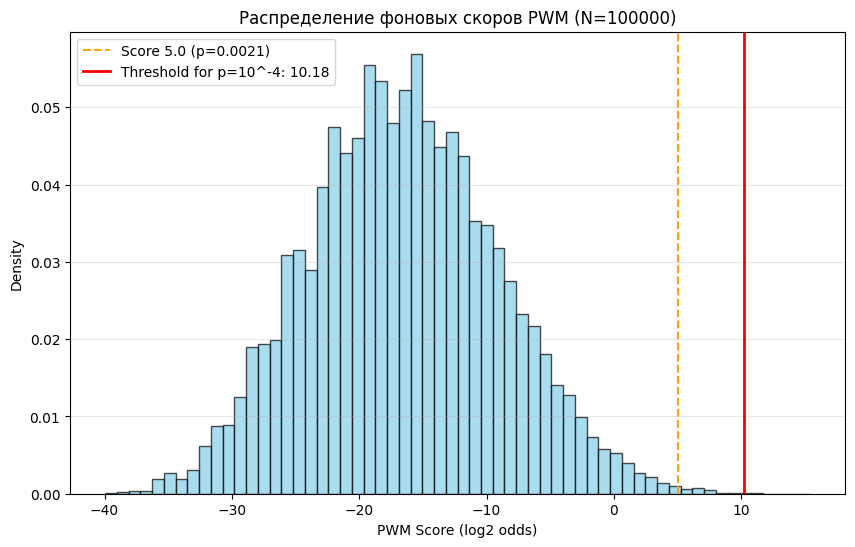

--- Результаты моделирования ---
Максимальный теоретический скор: 15.3846
Порог для p-value 10^-4: 10.1780
Вероятность встретить скор 5.0 случайно: 0.0021


In [11]:
import matplotlib.pyplot as plt

instances = [Seq(s) for s in sites]
m = motifs.create(instances)

background = {"A": 0.295, "C": 0.205, "G": 0.205, "T": 0.295}
m.background = background

# Переход PFM -> PPM -> PWM
pwm_obj = m.counts.normalize(pseudocounts=0.1).log_odds(background)

# Numpy извлечем веса в чистую матрицу (4 строки x 9 колонок)
# Порядок строк строго: A, C, G, T
pwm_np = np.array([pwm_obj[char] for char in "ACGT"])


N_SAMPLES = 100000
L = 9
bg_probs = [0.295, 0.205, 0.205, 0.295] # соответствуют A, C, G, T

# Генерация случайных индексов нуклеотидов (0=A, 1=C, 2=G, 3=T)
random_indices = np.random.choice([0, 1, 2, 3], size=(N_SAMPLES, L), p=bg_probs)

def calculate_scores_fast(indices, matrix):
    """Векторизованный расчет скоров для N последовательностей"""
    scores = np.zeros(indices.shape[0])
    for j in range(L):
        # Добавляем веса из j-го столбца для всех строк сразу
        scores += matrix[indices[:, j], j]
    return scores

# Считаем фоновые скоры
bg_scores = calculate_scores_fast(random_indices, pwm_np)

def get_pvalue(score, all_scores):
    """Доля фоновых скоров >= заданного score"""
    return np.sum(all_scores >= score) / len(all_scores)

# Ищем порог (threshold) для p-value ≈ 10^-4

target_p = 1e-4
threshold_10_4 = np.percentile(bg_scores, 100 * (1 - target_p))

plt.figure(figsize=(10, 6))
plt.hist(bg_scores, bins=60, color='skyblue', edgecolor='black', alpha=0.7, density=True)

# Линии порогов
plt.axvline(5.0, color='orange', linestyle='--', label=f'Score 5.0 (p={get_pvalue(5.0, bg_scores):.4f})')
plt.axvline(threshold_10_4, color='red', linewidth=2, label=f'Threshold for p=10^-4: {threshold_10_4:.2f}')

plt.title(f"Распределение фоновых скоров PWM (N={N_SAMPLES})")
plt.xlabel("PWM Score (log2 odds)")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Печать итогов
print(f"--- Результаты моделирования ---")
print(f"Максимальный теоретический скор: {np.sum(np.max(pwm_np, axis=0)):.4f}")
print(f"Порог для p-value 10^-4: {threshold_10_4:.4f}")
print(f"Вероятность встретить скор 5.0 случайно: {get_pvalue(5.0, bg_scores)}")

## 4. Энтропия и информационное содержание

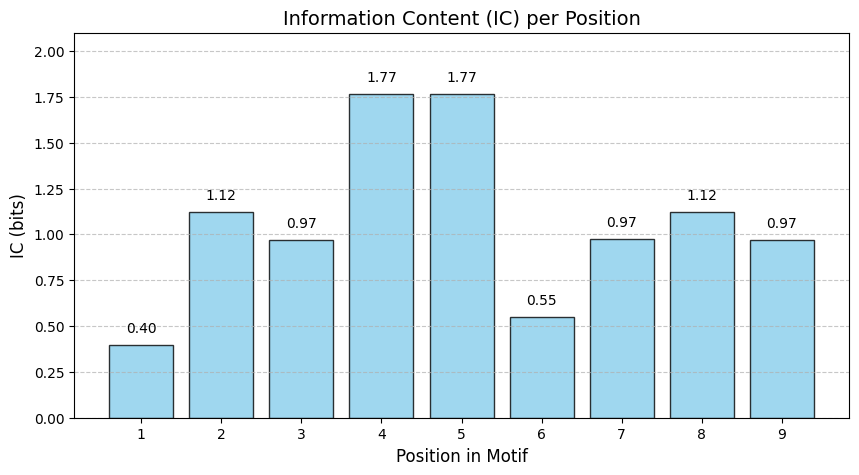

Значения IC по позициям:
Позиция 1: 0.397 бит
Позиция 2: 1.124 бит
Позиция 3: 0.969 бит
Позиция 4: 1.766 бит
Позиция 5: 1.766 бит
Позиция 6: 0.552 бит
Позиция 7: 0.975 бит
Позиция 8: 1.124 бит
Позиция 9: 0.969 бит


In [13]:
import matplotlib.pyplot as plt

ppm_np = ppm

def calculate_entropy(column):
    """Вычисляет энтропию Шеннона для одной колонки PPM"""
    entropy = 0
    for p in column:
        if p > 0:
            # Используем log2 согласно формуле Шеннона
            entropy -= p * np.log2(p)
    return entropy

# Расчет H(i) и IC(i) для каждой из 9 позиций
n_cols = ppm_np.shape[1]
# Считаем энтропию для каждой колонки (j)
entropies = np.array([calculate_entropy(ppm_np[:, j]) for j in range(n_cols)])
# Информационное содержание: Макс. энтропия (log2(4)=2) минус наблюдаемая
ic_values = 2 - entropies

# Построение столбчатой диаграммы
positions = np.arange(1, n_cols + 1)

plt.figure(figsize=(10, 5))
bars = plt.bar(positions, ic_values, color='skyblue', edgecolor='black', alpha=0.8)

# Оформление графика
plt.title("Information Content (IC) per Position", fontsize=14)
plt.xlabel("Position in Motif", fontsize=12)
plt.ylabel("IC (bits)", fontsize=12)
plt.ylim(0, 2.1)
plt.xticks(positions)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.2f}", ha='center', va='bottom')

plt.show()

print("Значения IC по позициям:")
for i, val in enumerate(ic_values):
    print(f"Позиция {i+1}: {val:.3f} бит")

Самыми важными для связывания являются позиции 4 и 5 там самые высокие значения, указывающие на почти полную консервативность нуклеотидов в этом месте. Также к кор-мотиву можно отнести позиции 2 и 8.

Визуальный осмотр подтверждает данные рассчета
В центре сайтов буквы почти никогда не меняются

#Часть II: Марковские цепи
##5. Матрица переходов для ДНК 1-го порядка

In [14]:
import numpy as np
from Bio import SeqIO

file_path = "chr1.fasta" #честно, я смотрела, последовательность не нашла - взяла старую

record = next(SeqIO.parse(file_path, "fasta"))
seq = str(record.seq[:10000]).upper()

# Алфавит
alphabet = "ACGT"
char_to_idx = {char: i for i, char in enumerate(alphabet)}

# Подсчет динуклеотидов и построение матрицы переходов
counts = np.zeros((4, 4))

for i in range(len(seq) - 1):
    curr_char = seq[i]
    next_char = seq[i+1]
    if curr_char in char_to_idx and next_char in char_to_idx:
        row = char_to_idx[curr_char]
        col = char_to_idx[next_char]
        counts[row, col] += 1

# Переход от частот к вероятностям
# P_ij = Count(ij) / Count(i)
transition_matrix = counts / counts.sum(axis=1, keepdims=True)

# Проверка суммы строк
row_sums = transition_matrix.sum(axis=1)

# Нахождение стационарного распределения
eigenvalues, eigenvectors = np.linalg.eig(transition_matrix.T)
# Ищем индекс собственного числа, максимально близкого к 1
idx = np.argmin(np.abs(eigenvalues - 1.0))
stationary = np.real(eigenvectors[:, idx])
stationary = stationary / stationary.sum() # Нормировка, чтобы сумма была 1

# Наблюдаемые частоты отдельных нуклеотидов
obs_freqs = np.array([seq.count(base) for base in alphabet])
obs_freqs = obs_freqs / obs_freqs.sum()


print("--- Матрица переходов 4x4 (P_ij) ---")
print("      A      C      G      T")
for i, char in enumerate(alphabet):
    print(f"{char} {transition_matrix[i]}")

print("\n--- Проверка суммы строк (должна быть 1.0) ---")
print(row_sums)

print("\n--- Сравнение распределений ---")
print(f"Нуклеотид:          {list(alphabet)}")
print(f"Стационарное (π):   {np.round(stationary, 4)}")
print(f"Наблюдаемое:        {np.round(obs_freqs, 4)}")
print(f"Разница (abs):      {np.round(np.abs(stationary - obs_freqs), 6)}")

--- Матрица переходов 4x4 (P_ij) ---
      A      C      G      T
A [0.22372881 0.24794189 0.38983051 0.13849879]
C [0.2506605  0.35997358 0.10138705 0.28797886]
G [0.19689119 0.30017271 0.34058722 0.16234888]
T [0.13625062 0.27697663 0.39632024 0.19045251]

--- Проверка суммы строк (должна быть 1.0) ---
[1. 1. 1. 1.]

--- Сравнение распределений ---
Нуклеотид:          ['A', 'C', 'G', 'T']
Стационарное (π):   [0.2065 0.3028 0.2895 0.2011]
Наблюдаемое:        [0.2065 0.3028 0.2895 0.2012]
Разница (abs):      [2.1e-05 3.0e-05 2.9e-05 8.0e-05]


## 6. Вычисление Pk и предельное распределение

---



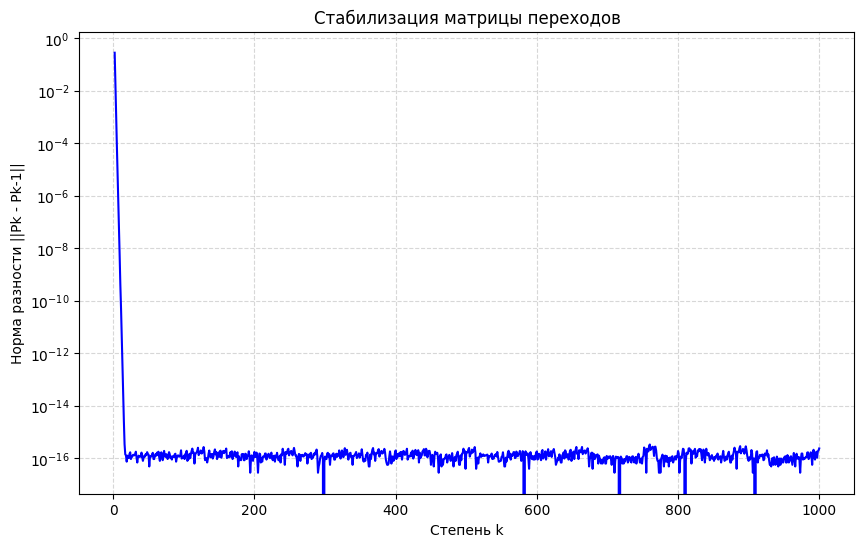

--- Матрица P в степени 1000 ---
[[0.206521 0.30283  0.289529 0.20112 ]
 [0.206521 0.30283  0.289529 0.20112 ]
 [0.206521 0.30283  0.289529 0.20112 ]
 [0.206521 0.30283  0.289529 0.20112 ]]

--- Проверка строк---
[1. 1. 1. 1.]

--- Сравнение строки матрицы P^1000 со стационарным вектором pi ---
Строка 1 матрицы P^1000: [0.206521 0.30283  0.289529 0.20112 ]
Стационарный вектор pi:  [0.206521 0.30283  0.289529 0.20112 ]

--- Сравнение с наблюдаемыми частотами ---
A: Предсказано (P^1000) = 0.206521, Наблюдаемо = 0.206500
C: Предсказано (P^1000) = 0.302830, Наблюдаемо = 0.302800
G: Предсказано (P^1000) = 0.289529, Наблюдаемо = 0.289500
T: Предсказано (P^1000) = 0.201120, Наблюдаемо = 0.201200


In [17]:
P = transition_matrix

k_max = 1000
norms = []
k_range = range(1, k_max + 1)

# Для графика нам нужны разности Pk - P_{k-1}
# Будем хранить предыдущую матрицу для расчета нормы
P_prev = np.eye(4) # Это P^0

for k in k_range:
    # Возводим матрицу в степень k
    P_k = np.linalg.matrix_power(P, k)

    # Считаем норму разности
    if k > 1:
        diff_norm = np.linalg.norm(P_k - P_prev, ord='fro')
        norms.append(diff_norm)

    # Сохраняем P_k как предыдущую для следующего шага
    P_prev = P_k

# График стабилизации
plt.figure(figsize=(10, 6))
plt.plot(range(2, k_max + 1), norms, color='blue', linewidth=1.5)
plt.yscale('log') # Логарифмическая шкала для визуализации экспоненциального затухания
plt.title("Стабилизация матрицы переходов")
plt.xlabel("Степень k")
plt.ylabel("Норма разности ||Pk - Pk-1||")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Печать финальной матрицы P^1000
print("--- Матрица P в степени 1000 ---")
print(P_k)

print("\n--- Проверка строк---")
print(P_k.sum(axis=1))

print("\n--- Сравнение строки матрицы P^1000 со стационарным вектором pi ---")
print(f"Строка 1 матрицы P^1000: {P_k[0, :]}")
print(f"Стационарный вектор pi:  {stationary}")

# Вывод частот нуклеотидов для сравнения
obs_freqs = np.array([seq.count(base) for base in alphabet]) / len(seq)
print("\n--- Сравнение с наблюдаемыми частотами ---")
for i, base in enumerate(alphabet):
    print(f"{base}: Предсказано (P^1000) = {P_k[0, i]:.6f}, Наблюдаемо = {obs_freqs[i]:.6f}")

## 7. CpG islands детектор

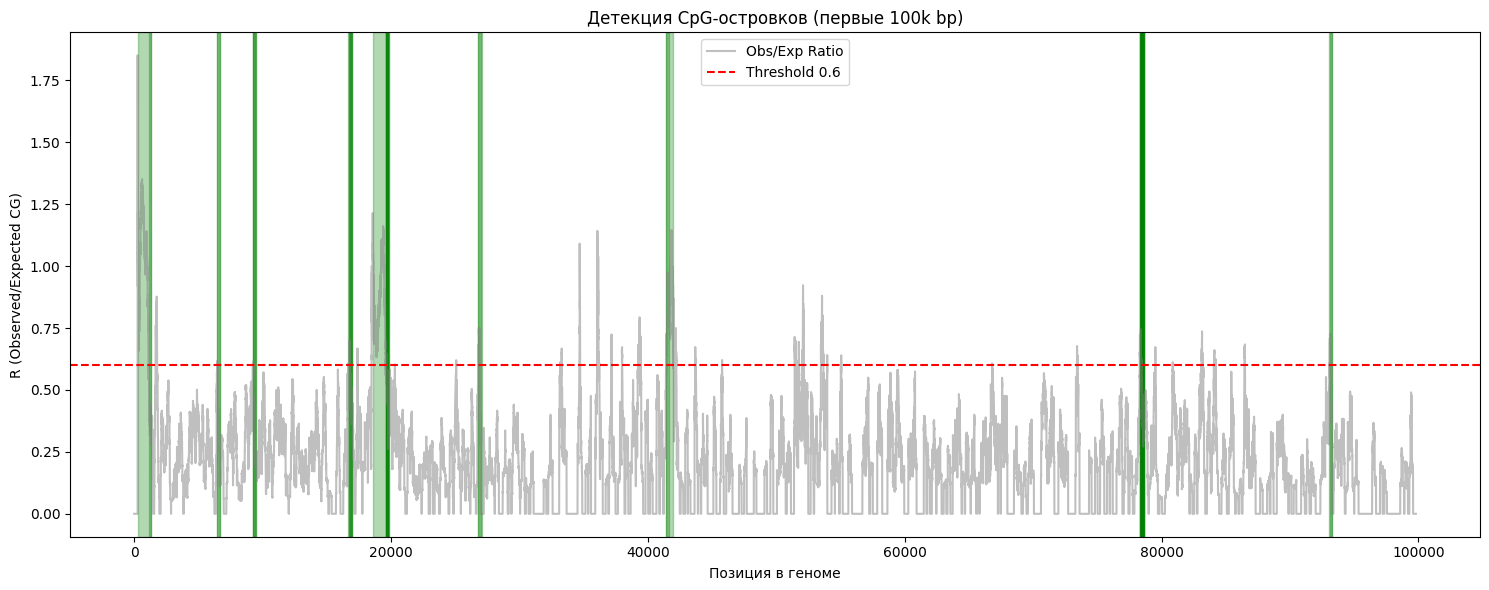

Найдено CpG-островков: 33
Координаты: 270 - 1320 bp
Координаты: 1147 - 1348 bp
Координаты: 6468 - 6668 bp
Координаты: 6470 - 6674 bp
Координаты: 9246 - 9446 bp
Координаты: 9270 - 9470 bp
Координаты: 9272 - 9472 bp
Координаты: 16672 - 16872 bp
Координаты: 16733 - 16946 bp
Координаты: 16751 - 16993 bp
Координаты: 16796 - 16997 bp
Координаты: 18625 - 19783 bp
Координаты: 19585 - 19785 bp
Координаты: 19590 - 19793 bp
Координаты: 19600 - 19803 bp
Координаты: 19607 - 19807 bp
Координаты: 19610 - 19845 bp
Координаты: 26786 - 27000 bp
Координаты: 26805 - 27048 bp
Координаты: 41433 - 41633 bp
Координаты: 41435 - 41990 bp
Координаты: 78293 - 78493 bp
Координаты: 78304 - 78507 bp
Координаты: 78309 - 78512 bp
Координаты: 78314 - 78517 bp
Координаты: 78319 - 78587 bp
Координаты: 78396 - 78596 bp
Координаты: 78408 - 78608 bp
Координаты: 78428 - 78637 bp
Координаты: 78439 - 78639 bp
Координаты: 78451 - 78651 bp
Координаты: 93063 - 93263 bp
Координаты: 93074 - 93280 bp


In [19]:
# Функция вычисления характеристик окна
def compute_cpg_stats(window):
    window = window.upper()
    length = len(window)
    if length == 0: return 0, 0

    # Считаем нуклеотиды и динуклеотид CG
    count_c = window.count('C')
    count_g = window.count('G')
    count_cg = window.count('CG')

    # GC%
    gc_percent = (count_c + count_g) / length * 100

    # Отношение Observed/Expected
    # Формула: R = P(CG) / (P(C) * P(G))
    # В терминах количеств: R = (count_cg * length) / (count_c * count_g)
    if count_c > 0 and count_g > 0:
        observed_expected_ratio = (count_cg * length) / (count_c * count_g)
    else:
        observed_expected_ratio = 0.0

    return observed_expected_ratio, gc_percent

# 2. Подготовка данных
record = SeqIO.read("chr1.fasta", "fasta")
sequence = str(record.seq[:100000]).upper()

# 3. Сканирование скользящим окном
window_size = 200
step = 1  # Для плавного графика используем шаг 1
r_values = []
islands = []

for i in range(0, len(sequence) - window_size, step):
    window = sequence[i : i + window_size]
    ratio, gc = compute_cpg_stats(window)
    r_values.append(ratio)

    # Проверка критериев Гардинера-Гардена
    if ratio > 0.6 and gc > 50:
        islands.append(i)

# Группировка позиций в интервалы для вывода координат
def get_intervals(positions):
    if not positions: return []
    intervals = []
    start = positions[0]
    for j in range(1, len(positions)):
        if positions[j] > positions[j-1] + 1:
            intervals.append((start, positions[j-1] + window_size))
            start = positions[j]
    intervals.append((start, positions[-1] + window_size))
    return intervals

found_intervals = get_intervals(islands)

# 4. Визуализация
plt.figure(figsize=(15, 6))
x_axis = np.arange(len(r_values))
plt.plot(x_axis, r_values, color='gray', alpha=0.5, label='Obs/Exp Ratio')

# Подсвечиваем найденные островки
for start, end in found_intervals:
    plt.axvspan(start, end, color='green', alpha=0.3)

plt.axhline(y=0.6, color='red', linestyle='--', label='Threshold 0.6')
plt.title("Детекция CpG-островков (первые 100k bp)")
plt.xlabel("Позиция в геноме")
plt.ylabel("R (Observed/Expected CG)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Найдено CpG-островков: {len(found_intervals)}")
for start, end in found_intervals:
    print(f"Координаты: {start} - {end} bp")

## 8. Симуляция марковской цепи

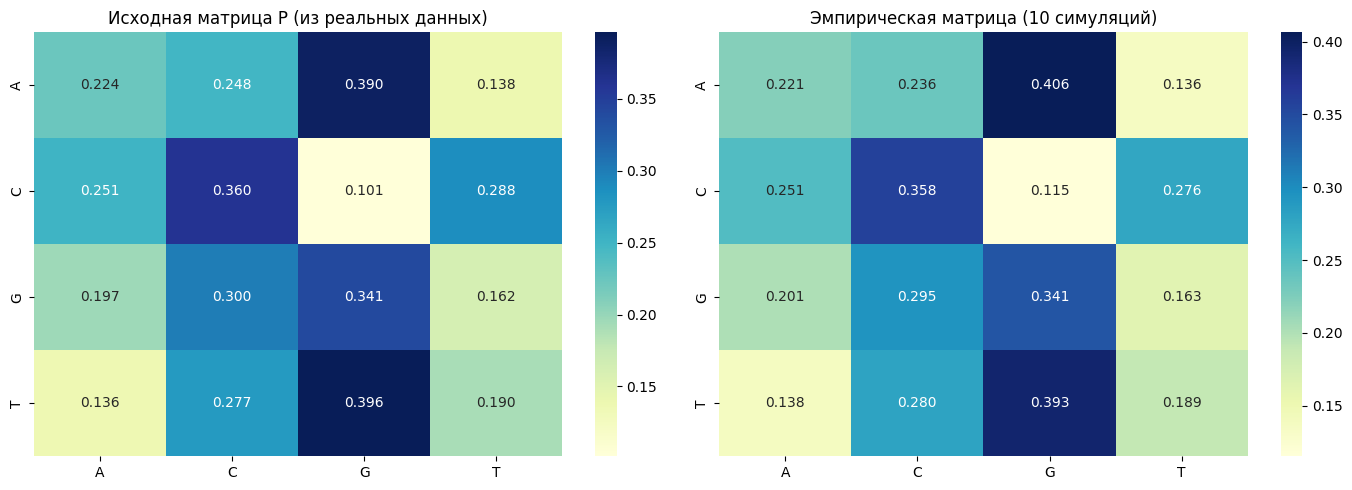

Средняя абсолютная разница между матрицами: 0.005151


In [20]:
import seaborn as sns

# 1. Функция генерации последовательности
def generate_sequence(P, length, start_state_idx):
    current_state = start_state_idx
    sequence_indices = [current_state]

    for _ in range(length - 1):
        # Выбираем следующий индекс нуклеотида на основе строки вероятностей P[current_state]
        next_state = np.random.choice([0, 1, 2, 3], p=P[current_state])
        sequence_indices.append(next_state)
        current_state = next_state

    return sequence_indices

n_seqs = 10
seq_length = 1000
all_generated_counts = np.zeros((4, 4))

for _ in range(n_seqs):
    # Начинаем со случайного нуклеотида
    start_idx = np.random.randint(0, 4)
    gen_seq = generate_sequence(P, seq_length, start_idx)

    # Подсчет динуклеотидов в сгенерированной последовательности
    for i in range(len(gen_seq) - 1):
        all_generated_counts[gen_seq[i], gen_seq[i+1]] += 1

# Эмпирическая матрица переходов (усредненная по 10 прогонам)
P_empirical = all_generated_counts / all_generated_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(P, annot=True, fmt=".3f", cmap="YlGnBu",
            xticklabels=list("ACGT"), yticklabels=list("ACGT"), ax=axes[0])
axes[0].set_title("Исходная матрица P (из реальных данных)")

sns.heatmap(P_empirical, annot=True, fmt=".3f", cmap="YlGnBu",
            xticklabels=list("ACGT"), yticklabels=list("ACGT"), ax=axes[1])
axes[1].set_title("Эмпирическая матрица (10 симуляций)")

plt.tight_layout()
plt.show()

# Расчет средней ошибки
mean_diff = np.mean(np.abs(P - P_empirical))
print(f"Средняя абсолютная разница между матрицами: {mean_diff:.6f}")

Эмпирическая матрица, полученная из сгенерированных последовательностей, очень близка к исходной матрице

## 9. Тест на марковость 0-го vs 1-го порядка

In [21]:
from scipy.stats import chi2

record = SeqIO.read("chr1.fasta", "fasta")
real_seq = str(record.seq[:10000]).upper()

# Создаем случайную последовательность (модель 0-го порядка) с теми же частотами
alphabet = "ACGT"
char_to_idx = {char: i for i, char in enumerate(alphabet)}
n = len(real_seq)

# Считаем частоты одиночных нуклеотидов в реальной последовательности
p_i = np.array([real_seq.count(base) / n for base in alphabet])

# Генерируем случайную строку на основе этих частот (нуклеотиды независимы)
rand_seq = "".join(np.random.choice(list(alphabet), size=n, p=p_i))

def perform_chi2_test(seq, p_probs, label):
    n_len = len(seq)
    # Матрица наблюдаемых частот O_ij (динуклеотиды)
    O = np.zeros((4, 4))
    for i in range(n_len - 1):
        if seq[i] in char_to_idx and seq[i+1] in char_to_idx:
            O[char_to_idx[seq[i]], char_to_idx[seq[i+1]]] += 1

    # Матрица ожидаемых частот E_ij = N * P(i) * P(j)
    E = np.zeros((4, 4))
    N_total = O.sum()
    for i in range(4):
        for j in range(4):
            E[i, j] = N_total * p_probs[i] * p_probs[j]

    # Статистика хи-квадрат
    chi_stat = np.sum((O - E)**2 / E)

    # P-value (степени свободы = (4-1)*(4-1) = 9)
    p_val = 1 - chi2.cdf(chi_stat, df=9)

    return O, E, chi_stat, p_val

# Выполняем расчеты
O_real, E_real, stat_real, p_real = perform_chi2_test(real_seq, p_i, "Реальный геном")
O_rand, E_rand, stat_rand, p_rand = perform_chi2_test(rand_seq, p_i, "Случайная последовательность")

# --- Вывод результатов ---
print(f"=== АНАЛИЗ: РЕАЛЬНЫЙ ГЕНОМ ===")
print(f"Статистика Chi2: {stat_real:.2f}, p-value: {p_real:.2e}")
print("Матрица наблюдаемых частот O_ij:\n", O_real)
print("Матрица ожидаемых частот E_ij:\n", np.round(E_real, 1))
conclusion_real = "Зависимость ЕСТЬ (нужна модель 1-го порядка)" if p_real < 0.05 else "Зависимости НЕТ"
print(f"Вывод: {conclusion_real}\n")

print(f"=== АНАЛИЗ: СЛУЧАЙНАЯ ПОСЛЕДОВАТЕЛЬНОСТЬ (0-й порядок) ===")
print(f"Статистика Chi2: {stat_rand:.2f}, p-value: {p_rand:.4f}")
conclusion_rand = "Зависимость ЕСТЬ" if p_rand < 0.05 else "Зависимости НЕТ (модель 0-го порядка верна)"
print(f"Вывод: {conclusion_rand}")

=== АНАЛИЗ: РЕАЛЬНЫЙ ГЕНОМ ===
Статистика Chi2: 862.49, p-value: 0.00e+00
Матрица наблюдаемых частот O_ij:
 [[ 462.  512.  805.  286.]
 [ 759. 1090.  307.  872.]
 [ 570.  869.  986.  470.]
 [ 274.  557.  797.  383.]]
Матрица ожидаемых частот E_ij:
 [[426.4 625.2 597.8 415.4]
 [625.2 916.8 876.5 609.2]
 [597.8 876.5 838.  582.4]
 [415.4 609.2 582.4 404.8]]
Вывод: Зависимость ЕСТЬ (нужна модель 1-го порядка)

=== АНАЛИЗ: СЛУЧАЙНАЯ ПОСЛЕДОВАТЕЛЬНОСТЬ (0-й порядок) ===
Статистика Chi2: 13.90, p-value: 0.1258
Вывод: Зависимости НЕТ (модель 0-го порядка верна)
